# 🧠 Brain Tumor MRI Classification Project

## Project Overview

- This project develops and evaluates deep learning models for **brain tumor MRI classification**.
- The dataset contains four classes:
  - **Glioma**
  - **Meningioma**
  - **Pituitary**
  - **No Tumor**
- A complete deep learning pipeline was implemented, including:
  - Data preprocessing
  - Transfer learning
  - Fine-tuning
  - Model evaluation
  - Explainable AI (XAI)
  - Model comparison
- A separate interactive Gradio demo is provided in:
  - `Brain_Tumor_Gradio_Demo.ipynb`

---

## Models Implemented

### Model 1 — ResNet18

- Pretrained on ImageNet.
- Trained using transfer learning and fine-tuning.
- Best checkpoint selected using **validation loss**.

### Model 2 — EfficientNet-B0

- Pretrained on ImageNet.
- Trained using the same pipeline for a fair comparison.
- Best checkpoint selected using **validation loss**.

---

## Notebook Organization

- The main notebook is divided into clearly labeled sections.
- Each code cell includes a short explanation describing its purpose.
- Results, evaluation metrics, visualizations, and XAI outputs are presented after each model.
- The Gradio interface is kept in a separate notebook to keep the main notebook focused on model development, evaluation, and explainability.

---

## Evaluation Strategy

- The original training dataset was split into:
  - **80% Training**
  - **20% Validation**
- The validation set was used for:
  - Model selection
  - Hyperparameter monitoring
  - Saving the best checkpoint
- The testing set was used only for final evaluation on unseen data.

### Main Hyperparameters

- Image size: **224 × 224**
- Batch size: **32**
- Train/Validation split: **80% / 20% (stratified)**
- Optimizer: **Adam**
- Feature extraction learning rate: **0.001**
- Fine-tuning learning rate: **0.0001**
- Feature extraction epochs: **5**
- Fine-tuning epochs: **10**
- Rotation augmentation: **±10°**
- Horizontal flip probability: **0.5**
- Random seed: **42**

---

## Comparison Criteria

The two models are compared using:

- Validation Loss
- Final Test Loss
- Final Test Accuracy
- Precision
- Recall
- F1-Score
- Confusion Matrix
- Grad-CAM Explainability (XAI)

---

## Interactive Gradio Demo

A separate interactive demo is provided in:

`Brain_Tumor_Gradio_Demo.ipynb`

The demo allows the user to:

- Run **ResNet18** individually.
- Run **EfficientNet-B0** individually.
- Compare both models on the same MRI image.
- View predicted class and model confidence.
- Inspect class probabilities.
- Generate **Grad-CAM** heatmaps.
- Flag selected MRI cases for later review.

Flagged cases are saved inside the:

`flagged_cases/`

folder together with the original MRI, Grad-CAM outputs, prediction information, true class metadata, and timestamp.

**No model retraining is performed inside the Gradio demo.**

---

## Reading Guide

The main notebook follows the following structure:

1. Data Loading
2. Dataset Exploration (EDA)
3. Preprocessing
4. Model Development
5. Transfer Learning & Fine-Tuning
6. Training
7. Validation & Evaluation
8. Explainable AI (XAI)
9. Model Comparison

The interactive demo is provided separately in:

`Brain_Tumor_Gradio_Demo.ipynb`

### ***"Each section in the main notebook contains the relevant code cells followed by a brief explanation of their purpose. The Gradio demo is provided separately to keep the main analysis notebook focused on model development, evaluation, and explainability."***

---------------

# 1. Data Loading

In [ ]:
# =========================
# Cell 1: Project Setup & Dataset Paths
# =========================

import os                       #file and folder operations
from pathlib import Path        #handling file paths

import matplotlib.pyplot as plt #Visualization library
from PIL import Image           #Image processing library

# Dataset paths
DATASET_DIR = Path("Brain Tumor MRI Dataset")
TRAIN_DIR = DATASET_DIR / "Training"
TEST_DIR  = DATASET_DIR / "Testing"

# Check paths
print("Dataset exists:", DATASET_DIR.exists())
print("Training exists:", TRAIN_DIR.exists())
print("Testing exists:", TEST_DIR.exists())

# Show class names
train_classes = sorted([folder.name for folder in TRAIN_DIR.iterdir() if folder.is_dir()])
test_classes  = sorted([folder.name for folder in TEST_DIR.iterdir() if folder.is_dir()])

print("\nTraining classes:", train_classes)
print("Testing classes:", test_classes)



Dataset exists: True
Training exists: True
Testing exists: True

Training classes: ['glioma', 'meningioma', 'notumor', 'pituitary']
Testing classes: ['glioma', 'meningioma', 'notumor', 'pituitary']


 - Defined dataset paths for training and testing folders.
 - Verified that the dataset directories exist.
 - Extracted class names from the folder structure.

-----------------------------------
# 2. Dataset Exploration 


In [126]:
# =========================
# Cell 2: Count Images
# =========================

def count_images(folder_path):
    counts = {}

    for class_name in sorted(os.listdir(folder_path)):
        class_path = folder_path / class_name

        if class_path.is_dir():
            num_images = len(os.listdir(class_path))
            counts[class_name] = num_images

    return counts


train_counts = count_images(TRAIN_DIR)
test_counts  = count_images(TEST_DIR)

print("Training Dataset Distribution:\n")
for cls, count in train_counts.items():
    print(f"{cls}: {count} images")

print("\n" + "="*40)

print("\nTesting Dataset Distribution:\n")
for cls, count in test_counts.items():
    print(f"{cls}: {count} images")



# This step was performed to understand the dataset structure

Training Dataset Distribution:

glioma: 1400 images
meningioma: 1400 images
notumor: 1400 images
pituitary: 1400 images


Testing Dataset Distribution:

glioma: 400 images
meningioma: 400 images
notumor: 400 images
pituitary: 400 images


 - Counted the number of images in each class.
 - Verified that the dataset is balanced across classes.

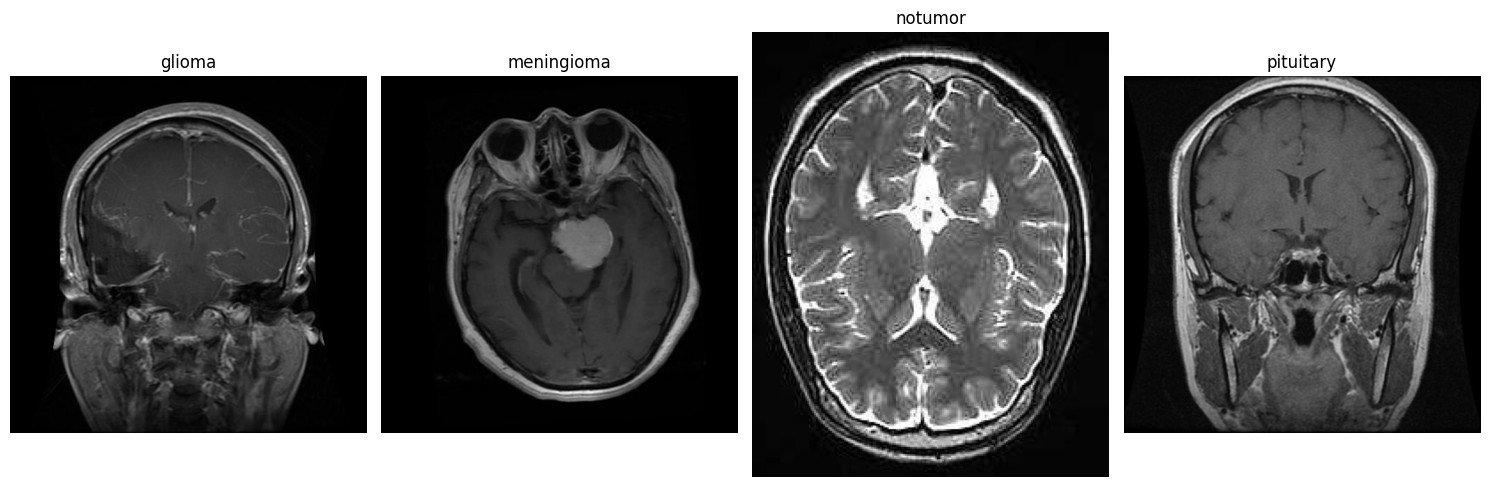

In [ ]:
# =========================
# Cell 3: MRI Sample Visualization
# =========================

fig, axes = plt.subplots(1, 4, figsize=(15,5))

for idx, class_name in enumerate(train_classes):

    class_path = TRAIN_DIR / class_name

    # first image from class
    image_name = os.listdir(class_path)[0]

    image_path = class_path / image_name

    # open image
    img = Image.open(image_path)

    # show image
    axes[idx].imshow(img, cmap='gray')
    axes[idx].set_title(class_name)
    axes[idx].axis("off")

plt.tight_layout()
plt.show()

 - Displayed sample MRI images from each class.
 - Helped understand image appearance before preprocessing.

In [128]:
# =========================
# Cell 4: Image Dimension Analysis
# =========================

image_sizes = []
image_modes = []

for class_name in train_classes:

    class_path = TRAIN_DIR / class_name

    # take few images from each class
    for image_name in os.listdir(class_path)[:20]:

        image_path = class_path / image_name

        img = Image.open(image_path)

        image_sizes.append(img.size)
        image_modes.append(img.mode)

# unique sizes
unique_sizes = set(image_sizes)

print("Unique Image Sizes:\n")
print(unique_sizes)

print("\n" + "="*50)

print("\nImage Modes:\n")
print(set(image_modes))



Unique Image Sizes:

{(528, 528), (200, 252), (512, 512), (201, 251), (225, 225), (630, 630), (442, 454), (275, 183), (192, 192), (234, 224), (442, 442), (215, 234), (393, 400), (236, 213), (626, 686), (236, 252), (236, 236), (232, 217)}


Image Modes:

{'RGB', 'L'}


 - Checked image sizes and image modes.
 - Confirmed that preprocessing is needed to make inputs consistent.
 ---------------------

# 3. Preprocessing

In [ ]:
# =========================
# Cell 5: Image Preprocessing and Augmentation

# =========================
import torch                                    #deep learning framework
from torchvision import datasets, transforms    #computer vision tasks - Datasets, transforms, pretrained models

IMAGE_SIZE = 224
BATCH_SIZE = 32

# Training transforms
train_transforms = transforms.Compose([

    # convert grayscale to RGB if needed
    transforms.Lambda(lambda img: img.convert("RGB")),

    # resize all images
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    # augmentation
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),

    # convert to tensor
    transforms.ToTensor(),          # scales pixel values to [0,1]  (normalization / scaling)

    # normalization
    transforms.Normalize(           # (standardization) standardizes them using ImageNet statistics
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Testing transforms                            #no augmentation for testing data
test_transforms = transforms.Compose([

    transforms.Lambda(lambda img: img.convert("RGB")),

    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),

    transforms.ToTensor(), 

    transforms.Normalize(                           
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

 - Created preprocessing pipelines for training, validation, and testing.
 - Applied resizing, RGB conversion, tensor conversion, normalization, and training augmentation.

In [ ]:
# =========================
# Cell 6: Datasets & DataLoaders
# =========================

from torch.utils.data import DataLoader, Subset         # Handling datasets during training
#DataLoader loads images in batches,  Subset helped create the train/validation split
from sklearn.model_selection import train_test_split     # Creates the train/validation split 

# Full training dataset with training transforms
full_train_dataset = datasets.ImageFolder(
    root=TRAIN_DIR,
    transform=train_transforms
)

# Same training folder, but validation uses test transforms
full_val_dataset = datasets.ImageFolder(
    root=TRAIN_DIR,
    transform=test_transforms
)

# Final test dataset
test_dataset = datasets.ImageFolder(
    root=TEST_DIR,
    transform=test_transforms
)

# Class names
CLASS_NAMES = full_train_dataset.classes

# Stratified train/validation split (preserving class distribution)
targets = full_train_dataset.targets

train_indices, val_indices = train_test_split(
    range(len(targets)),
    test_size=0.2,
    stratify=targets,
    random_state=42
)

train_dataset = Subset(full_train_dataset, train_indices)
val_dataset   = Subset(full_val_dataset, val_indices)

# DataLoaders               # Loads data in batches
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print("Classes:")
print(CLASS_NAMES)

print("\nTraining samples:", len(train_dataset))
print("Validation samples:", len(val_dataset))
print("Testing samples:", len(test_dataset))

Classes:
['glioma', 'meningioma', 'notumor', 'pituitary']

Training samples: 4480
Validation samples: 1120
Testing samples: 1600


 - Created training, validation, and testing datasets.
 - Split the original training data into train and validation subsets.
 - Created DataLoaders to load images in batches.

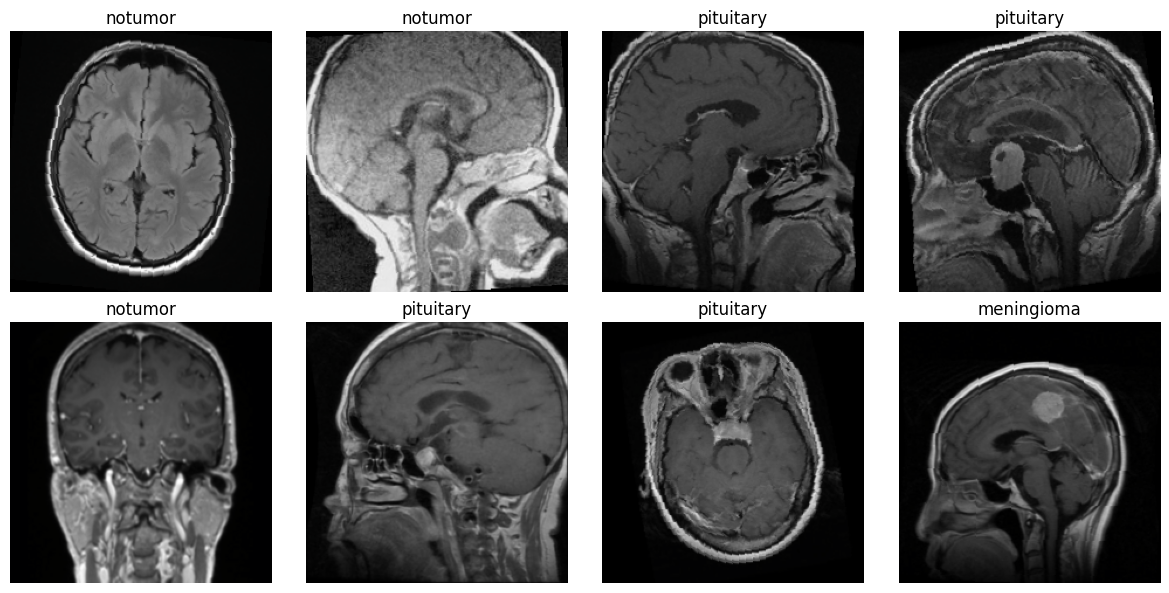

Batch shape: torch.Size([32, 3, 224, 224])


In [ ]:
# =========================
# Cell 7: Visualize Transformed Images, “Quality Check” before we give it to model    .
# =========================

# Get one batch
images, labels = next(iter(train_loader))

# Show first 8 images
fig, axes = plt.subplots(2, 4, figsize=(12,6))

for i, ax in enumerate(axes.flat):

    img = images[i]

    # convert tensor -> numpy
    img = img.permute(1, 2, 0).numpy()

    # unnormalize for display
    mean = [0.485, 0.456, 0.406]
    std  = [0.229, 0.224, 0.225]

    img = (img * std) + mean
    img = img.clip(0, 1)

    ax.imshow(img)

    ax.set_title(CLASS_NAMES[labels[i]])
    ax.axis("off")

plt.tight_layout()
plt.show()

# Print tensor shape
print("Batch shape:", images.shape)

Batch shape: torch.Size([batch size, RGB channels, height, width]) - this is the expected input shape for the models.
 - Displayed transformed training images.
 - Checked that preprocessing and augmentation did not distort the images.
 - Confirmed the expected tensor shape.

 ------------------

# 4. Model Development — ResNet18

In [132]:
# =========================
# Cell 8: Device Configuration
# =========================

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Using device:", DEVICE)
print(torch.cuda.get_device_name(0))


Using device: cuda
NVIDIA GeForce RTX 4050 Laptop GPU


 - Checked whether GPU is available.

In [ ]:
# =========================
# Cell 9: Load ResNet18
# =========================

from torchvision import models      # Loads pretrained ResNet18 and EfficientNet-B0 models
import torch.nn as nn               # Used to modify the final classification layer and define the loss function

# Load ResNet18 with pretrained ImageNet weights
model = models.resnet18(weights="DEFAULT")

# Get the number of features entering the original final fully connected layer
num_features = model.fc.in_features


# Replace the original final classification layer
# ResNet18 keeps its pretrained feature extractor,
# but the final layer is changed to output 4 scores for our classes
model.fc = nn.Linear(num_features, 4)

# Logic:
# MRI image
# -> ResNet18 extracts useful visual features
# -> model.fc receives those extracted features
# -> outputs 4 raw class scores (logits)
# -> one score for each class:
#    Glioma, Meningioma, Pituitary, No Tumor

# This prepares the pretrained ResNet18 for transfer learning



# Move model to GPU
model = model.to(DEVICE)

print(model)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

 - Loaded a pretrained ResNet18 model.
 - Replaced the final layer to output 4 classes.

----------

# 5. Transfer Learning / Freezing

In [ ]:
# =========================
# Cell 10: Freeze Backbone
# =========================

# Freeze all pretrained layers
for param in model.parameters():
    param.requires_grad = False

# Unfreeze final classification layer only - train only the new 4-class classifier
for param in model.fc.parameters():
    param.requires_grad = True

print("Backbone frozen.")
print("Only final layer will be trained.")

Backbone frozen.
Only final layer will be trained.


### Stage 1 — Feature Extraction

- The pretrained ResNet18 backbone is frozen, so its existing ImageNet weights are not updated during this stage.
- Only the new final classification layer (`model.fc`) remains trainable.
- The backbone continues to extract useful visual features, while the final layer learns how to map those features to the 4 MRI classes.

#### Why freeze the backbone first?

The pretrained model already contains useful visual features learned from ImageNet.  
Freezing the backbone allows the project to benefit from these pretrained features without changing them too early.

#### What if we did not freeze the backbone?

If the backbone was not frozen, all pretrained ResNet18 layers would start updating immediately during training.

This could:
- change the useful pretrained ImageNet features too quickly,
- make training less stable at the beginning,
- and increase the risk of overfitting, especially with a medical imaging dataset that is much smaller than ImageNet.

That is why the project first trains only the new final classifier, then later unfreezes the backbone for fine-tuning with a lower learning rate.

#### Training Strategy

- **Stage 1:** Freeze backbone → train final layer only.
- **Stage 2:** Unfreeze backbone → fine-tune the full model using a lower learning rate.

------------

# 6. Training Setup

In [ ]:
# =========================
# Cell 11: Loss & Optimizer
# =========================

import torch.optim as optim          # Provides the Adam optimizer used to update trainable model weights

# Loss function
criterion = nn.CrossEntropyLoss()

# Optimizer
optimizer = optim.Adam(
    model.fc.parameters(),
    lr=0.001
)

print("Loss Function:", criterion)
print("Optimizer:", optimizer)

Loss Function: CrossEntropyLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.001
    maximize: False
    weight_decay: 0
)



- Defined **CrossEntropyLoss** (measures the classification error between the model predictions and the true labels.)
- Used **Adam optimizer** (updates the trainable weights to reduce that loss.)
- **Learning rate = 0.001** controls how big each update is

**Image → prediction → loss → optimizer updates trainable weights**

-------------------

In [136]:
# =========================
# Cell 12: Training Function
# =========================

def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        # Reset gradients
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Calculate loss
        loss = criterion(outputs, labels)

        # Backward pass
        loss.backward()

        # Update weights
        optimizer.step()

        # Statistics
        running_loss += loss.item() * images.size(0)

        _, preds = torch.max(outputs, 1)
        correct_predictions += (preds == labels).sum().item()
        total_samples += labels.size(0)

    epoch_loss = running_loss / total_samples
    epoch_acc = correct_predictions / total_samples

    return epoch_loss, epoch_acc

### Training Function Logic

This function trains the model for **one full epoch** by going through all training batches until it has processed the entire training dataset once..

For each batch:

**Images → Forward Pass → CrossEntropyLoss → Backpropagation → Adam updates the trainable weights**

During Stage 1, only the final classifier (`model.fc`) is updated because the ResNet18 backbone is still frozen.

At the end of the epoch, the function returns:
- Average training loss
- Training accuracy

-----------

In [ ]:
# =========================
# Cell 13: Validation Function
# =========================

def evaluate(model, dataloader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct_predictions = 0
    total_samples = 0

    with torch.no_grad():

        for images, labels in dataloader:

            images = images.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(images)

            # Loss
            loss = criterion(outputs, labels)

            # Statistics
            running_loss += loss.item() * images.size(0)

            _, preds = torch.max(outputs, 1)

            correct_predictions += (preds == labels).sum().item()
            total_samples += labels.size(0)

    epoch_loss = running_loss / total_samples
    epoch_acc = correct_predictions / total_samples

    return epoch_loss, epoch_acc

### Evaluation Function Logic

This function evaluates the model on validation or test data **without updating the model weights**.

For each batch:

**Images → Forward Pass → CrossEntropyLoss → Predictions → Accuracy**

Unlike training:
- No backpropagation is performed.
- Adam does not update any weights.
- `torch.no_grad()` is used to avoid unnecessary gradient calculations.

At the end, the function returns:
- Average evaluation loss
- Evaluation accuracy

During training, this function is mainly used on the validation set to monitor generalization and detect overfitting.

------------

# 7. Model Training & Fine-Tuning

In [ ]:
# =========================
# Cell 14: Stage 1: Main Training Loop
# =========================

EPOCHS = 5

train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []

for epoch in range(EPOCHS):

    print(f"\nEpoch {epoch+1}/{EPOCHS}")
    print("-" * 30)

    # Training
    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        DEVICE
    )

    # Validation
    val_loss, val_acc = evaluate(
        model,
        val_loader,
        criterion,
        DEVICE
    )

    # Store results
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train Accuracy: {train_acc:.4f}")

    print(f"Validation Loss: {val_loss:.4f}")
    print(f"Validation Accuracy: {val_acc:.4f}")


Epoch 1/5
------------------------------
Train Loss: 0.7232
Train Accuracy: 0.7404
Validation Loss: 0.5009
Validation Accuracy: 0.8321

Epoch 2/5
------------------------------
Train Loss: 0.4668
Train Accuracy: 0.8379
Validation Loss: 0.4215
Validation Accuracy: 0.8491

Epoch 3/5
------------------------------
Train Loss: 0.4154
Train Accuracy: 0.8511
Validation Loss: 0.4234
Validation Accuracy: 0.8348

Epoch 4/5
------------------------------
Train Loss: 0.3799
Train Accuracy: 0.8627
Validation Loss: 0.3933
Validation Accuracy: 0.8455

Epoch 5/5
------------------------------
Train Loss: 0.3645
Train Accuracy: 0.8661
Validation Loss: 0.3743
Validation Accuracy: 0.8571


- Trained ResNet18 for **5 epochs** while keeping the pretrained backbone frozen.
- Only the new final classification layer (`model.fc`) was updated.
- After each epoch, the model was evaluated on the validation set.
- Training and validation loss/accuracy were recorded for later comparison and monitoring.

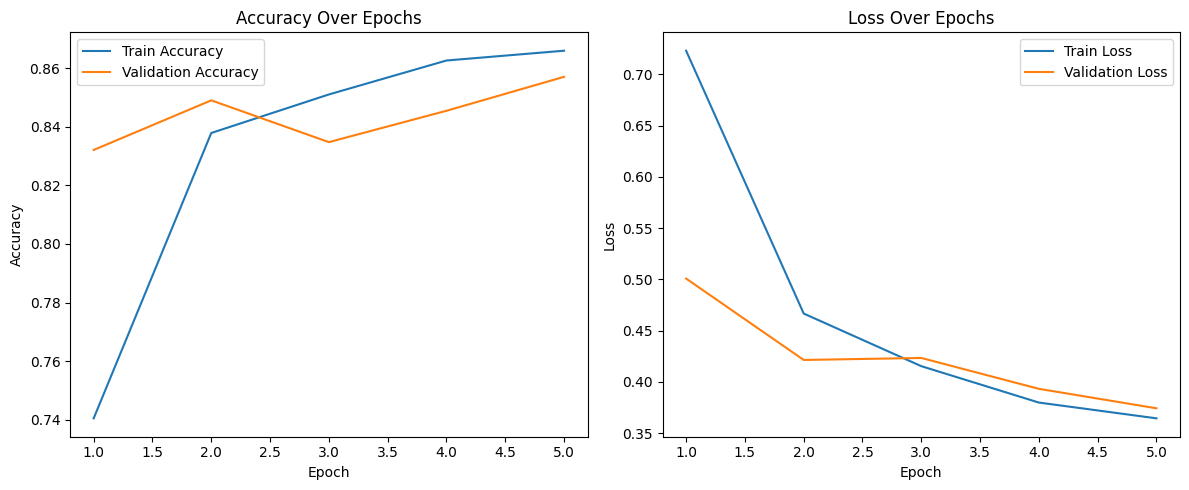

In [ ]:
# =========================
# Cell 15: Stage 1: Initial Learning Curves
# =========================

epochs_range = range(1, EPOCHS + 1)

plt.figure(figsize=(12,5))

# Accuracy plot
plt.subplot(1,2,1)

plt.plot(epochs_range, train_accuracies, label="Train Accuracy")
plt.plot(epochs_range, val_accuracies, label="Validation Accuracy")

plt.title("Accuracy Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")

plt.legend()

# Loss plot
plt.subplot(1,2,2)

plt.plot(epochs_range, train_losses, label="Train Loss")
plt.plot(epochs_range, val_losses, label="Validation Loss")

plt.title("Loss Over Epochs")
plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.legend()

plt.tight_layout()
plt.show()

- Plotted training and validation accuracy/loss during the first training stage.

In [ ]:
# =========================
# Cell 16: Stage 2: Fine-Tuning Setup
# =========================

# Unfreeze the entire model
for param in model.parameters():
    param.requires_grad = True

# New optimizer with smaller learning rate
optimizer = optim.Adam(
    model.parameters(),
    lr=0.0001
)

print("Fine-tuning enabled.")
print("All layers are now trainable.")

Fine-tuning enabled.
All layers are now trainable.


### Stage 2 — Fine-Tuning Setup
Unfreeze full model → fine-tune all layers with smaller learning rate
- Unfroze all ResNet18 layers so the full model can now be updated.
- Created a new Adam optimizer to update all model parameters using the lower fine-tuning learning rate.
- Reduced the learning rate from **0.001** to **0.0001** to update the pretrained weights more carefully.

In [ ]:
# =========================
# Cell 17: Stage 2: Fine-Tuning Training Loop
# =========================

FINE_TUNE_EPOCHS = 10

# Best model tracking based on validation loss
best_val_loss = float("inf")
best_epoch = 0

for epoch in range(FINE_TUNE_EPOCHS):

    print(f"\nFine-Tuning Epoch {epoch+1}/{FINE_TUNE_EPOCHS}")
    print("-" * 40)

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        DEVICE
    )

    val_loss, val_acc = evaluate(
        model,
        val_loader,
        criterion,
        DEVICE
    )

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    # Save best model based on validation loss
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_epoch = EPOCHS + epoch + 1

        torch.save(model.state_dict(), "best_resnet18.pth")

        print("Best ResNet18 model saved.")

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train Accuracy: {train_acc:.4f}")

    print(f"Validation Loss: {val_loss:.4f}")
    print(f"Validation Accuracy: {val_acc:.4f}")

print(f"\nBest ResNet18 Epoch: {best_epoch}")
print(f"Best Validation Loss: {best_val_loss:.4f}")


Fine-Tuning Epoch 1/10
----------------------------------------
Best ResNet18 model saved.
Train Loss: 0.2307
Train Accuracy: 0.9190
Validation Loss: 0.1320
Validation Accuracy: 0.9580

Fine-Tuning Epoch 2/10
----------------------------------------
Best ResNet18 model saved.
Train Loss: 0.0747
Train Accuracy: 0.9737
Validation Loss: 0.0908
Validation Accuracy: 0.9670

Fine-Tuning Epoch 3/10
----------------------------------------
Best ResNet18 model saved.
Train Loss: 0.0626
Train Accuracy: 0.9790
Validation Loss: 0.0898
Validation Accuracy: 0.9634

Fine-Tuning Epoch 4/10
----------------------------------------
Best ResNet18 model saved.
Train Loss: 0.0413
Train Accuracy: 0.9846
Validation Loss: 0.0673
Validation Accuracy: 0.9786

Fine-Tuning Epoch 5/10
----------------------------------------
Train Loss: 0.0400
Train Accuracy: 0.9871
Validation Loss: 0.0805
Validation Accuracy: 0.9750

Fine-Tuning Epoch 6/10
----------------------------------------
Best ResNet18 model saved.
Train

### Stage 2 — Fine-Tuning

- Fine-tuned the full ResNet18 model for **10 epochs** after unfreezing all layers.
- Used the lower learning rate of **0.0001**.
- After each epoch, the model was evaluated on the validation set.
- Saved the best model checkpoint whenever the validation loss improved.

**That checkpoint logic is important because the last epoch is not always the best epoch.**

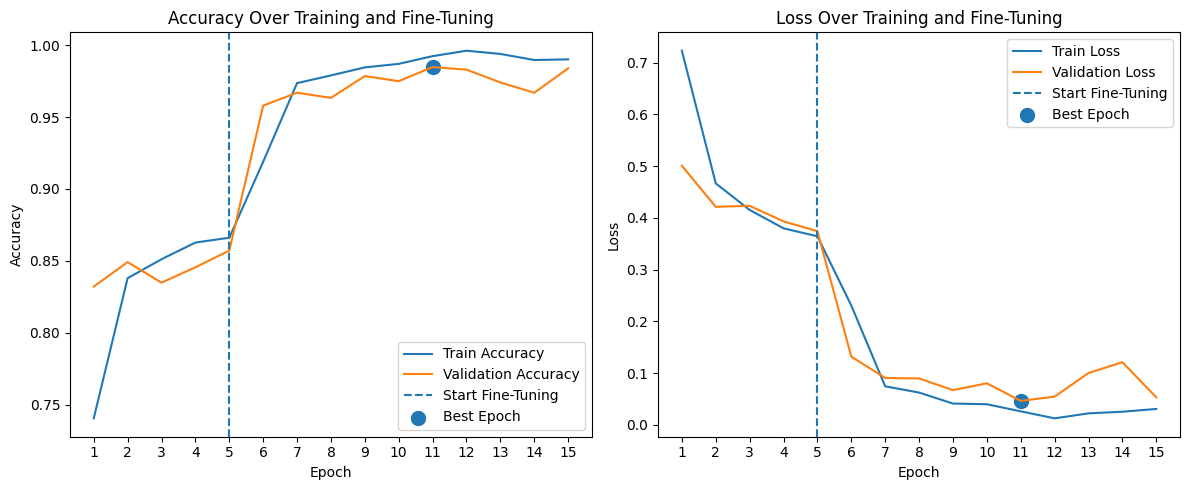

In [ ]:
# =========================
# Cell 18: Plot Resnet18 Full Learning Curves
# =========================

total_epochs = range(1, len(train_losses) + 1)

BEST_EPOCH = best_epoch

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)

plt.plot(total_epochs, train_accuracies, label="Train Accuracy")
plt.plot(total_epochs, val_accuracies, label="Validation Accuracy")

plt.axvline(
    x=EPOCHS,
    linestyle="--",
    label="Start Fine-Tuning"
)

plt.scatter(
    BEST_EPOCH,
    val_accuracies[BEST_EPOCH - 1],
    s=100,
    label="Best Epoch"
)

plt.title("Accuracy Over Training and Fine-Tuning")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(list(total_epochs))
plt.legend()

# Loss
plt.subplot(1,2,2)

plt.plot(total_epochs, train_losses, label="Train Loss")
plt.plot(total_epochs, val_losses, label="Validation Loss")

plt.axvline(
    x=EPOCHS,
    linestyle="--",
    label="Start Fine-Tuning"
)

plt.scatter(
    BEST_EPOCH,
    val_losses[BEST_EPOCH - 1],
    s=100,
    label="Best Epoch"
)

plt.title("Loss Over Training and Fine-Tuning")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(list(total_epochs))
plt.legend()

plt.tight_layout()
plt.show()

- Visualized the complete ResNet18 training history across both stages:
  - Stage 1: feature extraction
  - Stage 2: fine-tuning
- The vertical line marks the start of fine-tuning.
- The best epoch is highlighted based on the lowest validation loss.

------------

# 8. Validation & Evaluation — ResNet18

In [ ]:
# =========================
# Cell 19: Load Best ResNet18 and Final Test Evaluation
# =========================

model.load_state_dict(torch.load("best_resnet18.pth"))
model.eval()

final_test_loss, final_test_acc = evaluate(
    model,
    test_loader,
    criterion,
    DEVICE
)

print("Best validation-checkpoint ResNet18 model loaded successfully.")
print(f"Final Test Loss: {final_test_loss:.4f}")
print(f"Final Test Accuracy: {final_test_acc:.4f}")

Best validation-checkpoint ResNet18 model loaded successfully.
Final Test Loss: 0.4325
Final Test Accuracy: 0.9356


### Final Test Evaluation — ResNet18

- Loaded the best ResNet18 checkpoint selected using the lowest validation loss.
- Evaluated this best model on the unseen test set.
- Reported the final test loss and final test accuracy.

**Workflow:**  
Training + Validation → Save Best Checkpoint → Load Best Checkpoint → Final Test Evaluation

In [144]:
# =========================
# Cell 20: Generate Predictions for Evaluation
# =========================

from sklearn.metrics import confusion_matrix, classification_report
import numpy as np

all_preds = []
all_labels = []

model.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(DEVICE)
        labels = labels.to(DEVICE)

        outputs = model(images)
        _, preds = torch.max(outputs, 1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)

print("Predictions generated successfully.")

Predictions generated successfully.


### Generate Test Predictions

**Test images → Model predictions → Store predicted labels + true labels → Detailed evaluation**

- Generated predictions for all images in the test set using the best ResNet18 checkpoint.
- Stored the predicted classes and true labels.
- These results are used next for the confusion matrix and classification report.

**Difference from Cell 19:**
- Cell 19 → overall final performance (`test loss` and `test accuracy`)
- Cell 20 → stores individual predictions for detailed evaluation

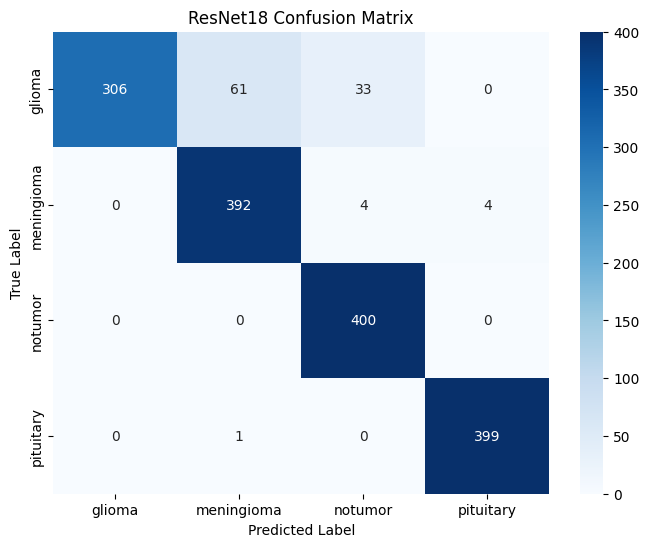

In [ ]:
# =========================
# Cell 21: Confusion Matrix
# =========================

import seaborn as sns       # Used to visualize the confusion matrix as a heatmap

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.title("ResNet18 Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

 - Visualized correct and incorrect predictions across classes.

In [ ]:
# =========================
# Cell 22: Classification Report
# =========================

report = classification_report(
    all_labels,
    all_preds,
    target_names=CLASS_NAMES
)

print(report)

              precision    recall  f1-score   support

      glioma       1.00      0.77      0.87       400
  meningioma       0.86      0.98      0.92       400
     notumor       0.92      1.00      0.96       400
   pituitary       0.99      1.00      0.99       400

    accuracy                           0.94      1600
   macro avg       0.94      0.94      0.93      1600
weighted avg       0.94      0.94      0.93      1600



### Classification Report — ResNet18

For each class:

- **Precision** = when the model predicts this class, how often is it correct?
- **Recall** = out of all real images of this class, how many did the model detect?
- **F1-score** = balance between precision and recall.
- **Support** = number of real test images in that class.

| Class | Precision | Recall | F1 | What it means |
|---|---:|---:|---:|---|
| Glioma | 1.00 | 0.77 | 0.87 | Very precise when predicting glioma, but missed some real glioma cases |
| Meningioma | 0.86 | 0.98 | 0.92 | Found almost all real meningioma cases, but some other classes were predicted as meningioma |
| No Tumor | 0.92 | 1.00 | 0.96 | Found all no-tumor images, but some tumor images were also predicted as no-tumor |
| Pituitary | 0.99 | 1.00 | 0.99 | Almost perfect performance |

### Key Observation

Glioma had:
- Precision = **1.00**
- Recall = **0.77**

So the model was very reliable when it predicted glioma, but it detected only about **77% of real glioma cases**, missing around **23%**.

### Overall Metrics

- **Accuracy = 0.94** → about 94% of all test images were classified correctly.
- **Macro avg** → simple average across all classes; each class contributes equally (**25% each**).
- **Weighted avg** → average weighted by the number of samples in each class.

In this project, each class has **400 samples**, so macro and weighted averages are almost the same.

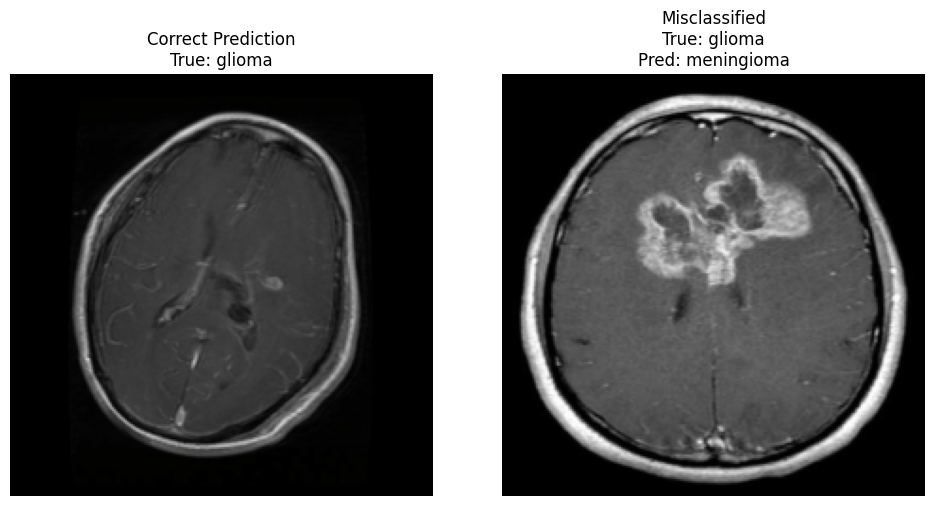

In [ ]:
# =========================
# Cell 23: Correct vs Misclassified
# =========================

correct_sample = None
wrong_sample = None
wrong_pred = None

model.eval()

with torch.no_grad():

    for imgs, labels in test_loader:

        preds = model(imgs.to(DEVICE)).argmax(1).cpu()

        for img, lbl, pred in zip(imgs, labels, preds):

            if lbl.item() == pred.item() and correct_sample is None:
                correct_sample = (img, lbl)

            if lbl.item() != pred.item() and wrong_sample is None:
                wrong_sample = (img, lbl)
                wrong_pred = pred.item()

        if correct_sample is not None and wrong_sample is not None:
            break

fig, axes = plt.subplots(1, 2, figsize=(10,5))

samples = [
    (correct_sample[0], correct_sample[1], "Correct Prediction"),
    (wrong_sample[0], wrong_sample[1], "Misclassified")
]

for ax, (img, lbl, title) in zip(axes, samples):

    img = img.permute(1, 2, 0).numpy()

    mean = [0.485, 0.456, 0.406]
    std  = [0.229, 0.224, 0.225]

    img = (img * std) + mean
    img = img.clip(0, 1)

    ax.imshow(img)

    if title == "Correct Prediction":
        ax.set_title(f"{title}\nTrue: {CLASS_NAMES[lbl]}")
    else:
        ax.set_title(
            f"{title}\nTrue: {CLASS_NAMES[lbl]}\nPred: {CLASS_NAMES[wrong_pred]}"
        )

    ax.axis("off")

plt.tight_layout()
plt.show()

- Displayed one correctly classified and one misclassified test image.
- Provided qualitative examples of how the ResNet18 model behaves on individual MRI images.

---------------------

# 9. Explainable AI (XAI) & Model Saving — ResNet18

In [ ]:
# =========================
# Cell 24: Grad-CAM Setup
# =========================

from pytorch_grad_cam import GradCAM                                    #generates the attention/importance heatmap.
from pytorch_grad_cam.utils.image import show_cam_on_image              #overlays that heatmap on the MRI image.
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget #tells Grad-CAM which predicted class we want to explain.

 - Imported Grad-CAM tools for explainability.

In [149]:
# =========================
# Cell 25: Prepare Correct Image for Grad-CAM
# =========================

correct_sample = None

model.eval()

with torch.no_grad():
    for img, label in test_dataset:
        input_tensor = img.unsqueeze(0).to(DEVICE)
        output = model(input_tensor)
        pred = output.argmax(1).item()

        if pred == label:
            correct_sample = (img, label, pred)
            break

image_tensor, true_label, predicted_class = correct_sample
input_tensor = image_tensor.unsqueeze(0).to(DEVICE)

print("True Label:", CLASS_NAMES[true_label])
print("Predicted Label:", CLASS_NAMES[predicted_class])

True Label: glioma
Predicted Label: glioma


 - Selected a correctly classified test image.
 - Prepared it for Grad-CAM visualization.

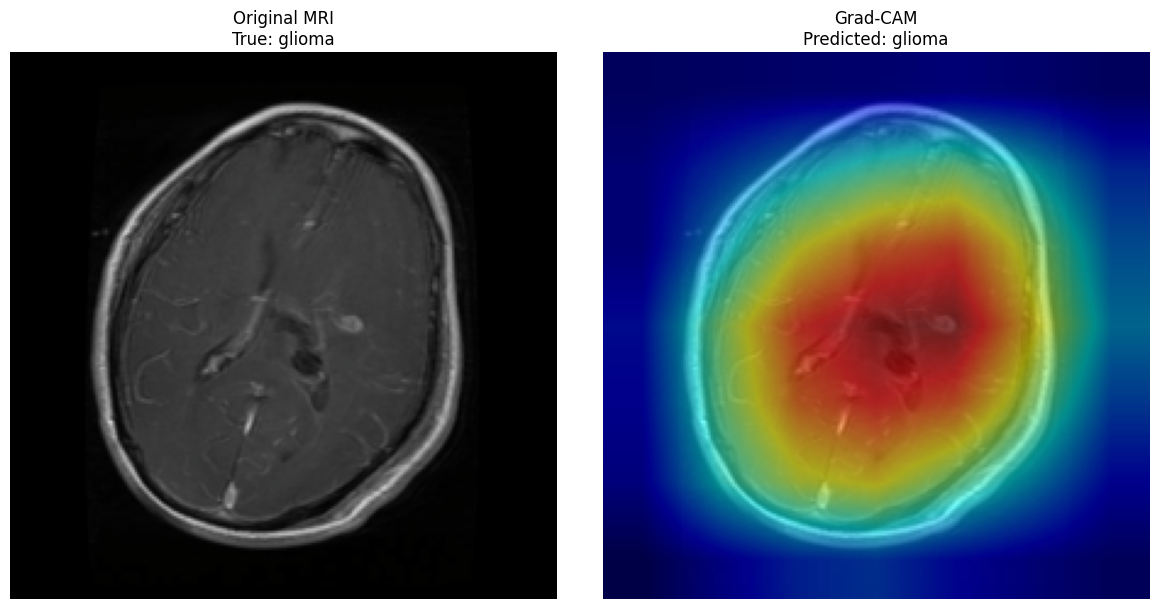

In [150]:
# =========================
# Cell 26: Generate Grad-CAM Heatmap
# =========================

target_layers = [model.layer4[-1]]

cam = GradCAM(
    model=model,
    target_layers=target_layers
)

targets = [ClassifierOutputTarget(predicted_class)]

grayscale_cam = cam(
    input_tensor=input_tensor,
    targets=targets
)

grayscale_cam = grayscale_cam[0, :]

# Prepare original image for display
rgb_img = image_tensor.permute(1, 2, 0).numpy()

mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

rgb_img = (rgb_img * std) + mean
rgb_img = rgb_img.clip(0, 1)

visualization = show_cam_on_image(
    rgb_img,
    grayscale_cam,
    use_rgb=True
)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(rgb_img)
axes[0].set_title(f"Original MRI\nTrue: {CLASS_NAMES[true_label]}")
axes[0].axis("off")

axes[1].imshow(visualization)
axes[1].set_title(f"Grad-CAM\nPredicted: {CLASS_NAMES[predicted_class]}")
axes[1].axis("off")

plt.tight_layout()
plt.show()

- Generated a Grad-CAM heatmap for a correctly classified MRI image.
- Warmer regions indicate areas that had a stronger influence on the model's prediction.
- Grad-CAM provides a rough explanation of model attention; it is not an exact tumor segmentation.

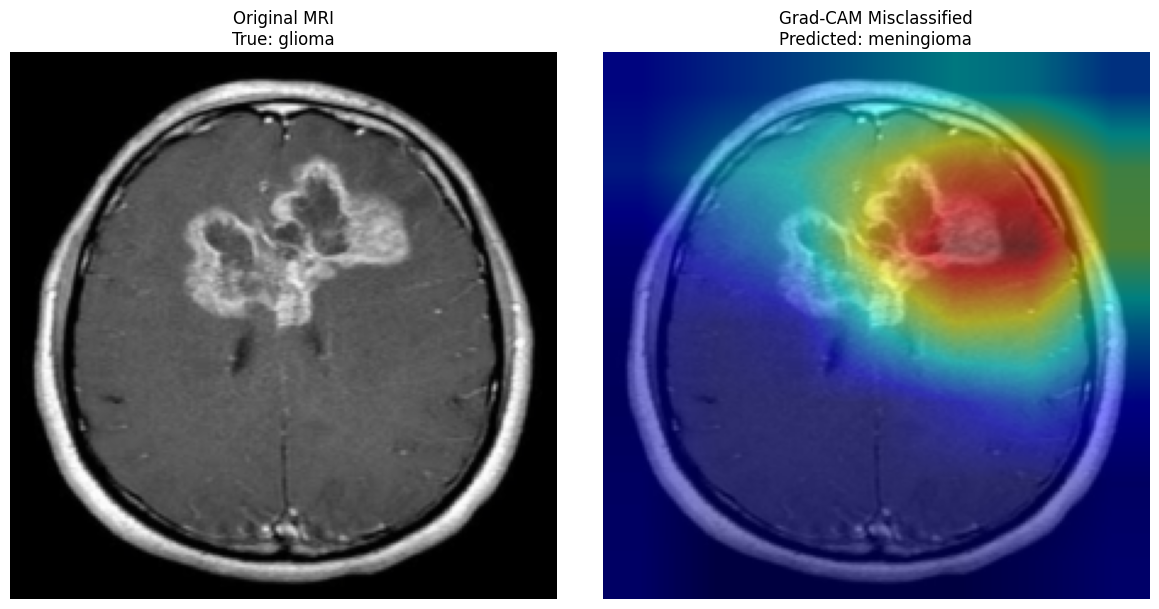

In [151]:
# =========================
# Cell 27: Grad-CAM for Misclassified Image
# =========================

misclassified_sample = None

model.eval()

with torch.no_grad():

    for img, label in test_dataset:

        input_tensor = img.unsqueeze(0).to(DEVICE)

        output = model(input_tensor)
        pred = output.argmax(1).item()

        if pred != label:
            misclassified_sample = (img, label, pred)
            break

image_tensor, true_label, predicted_class = misclassified_sample
input_tensor = image_tensor.unsqueeze(0).to(DEVICE)

target_layers = [model.layer4[-1]]

cam = GradCAM(
    model=model,
    target_layers=target_layers
)

targets = [ClassifierOutputTarget(predicted_class)]

grayscale_cam = cam(
    input_tensor=input_tensor,
    targets=targets
)

grayscale_cam = grayscale_cam[0, :]

rgb_img = image_tensor.permute(1, 2, 0).numpy()

mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

rgb_img = (rgb_img * std) + mean
rgb_img = rgb_img.clip(0, 1)

visualization = show_cam_on_image(
    rgb_img,
    grayscale_cam,
    use_rgb=True
)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(rgb_img)
axes[0].set_title(f"Original MRI\nTrue: {CLASS_NAMES[true_label]}")
axes[0].axis("off")

axes[1].imshow(visualization)
axes[1].set_title(
    f"Grad-CAM Misclassified\nPredicted: {CLASS_NAMES[predicted_class]}"
)
axes[1].axis("off")

plt.tight_layout()
plt.show()

- Selected a misclassified test image and generated its Grad-CAM heatmap.
- Compared the true class with the incorrect predicted class.
- The heatmap helps inspect which image regions influenced the incorrect prediction.

- The model still focused mainly around the abnormal region, suggesting that the error may be related to visual similarity between tumor classes rather than irrelevant background features.

-------------------

# 10. Model 2 — EfficientNet-B0


1 - Load pretrained EfficientNet-B0

2 - Replace final classifier with 4 outputs

3 - Freeze backbone

4 - Train final classifier for 5 epochs

5 - Unfreeze all layers

6 - Fine-tune for 10 epochs with lower learning rate

7 - Save best EfficientNet model based on validation loss

8 - Plot learning curves

9 - Load best model and evaluate on test set

10 - Generate confusion matrix + classification report

11 - Compare EfficientNet-B0 vs ResNet18

In [ ]:
# =========================
# Cell 28: Load EfficientNet-B0
# =========================

from torchvision.models import efficientnet_b0, EfficientNet_B0_Weights
import torch.nn as nn

# Load pretrained EfficientNet-B0
model_eff = efficientnet_b0(
    weights=EfficientNet_B0_Weights.DEFAULT
)

# Replace classifier for 4 classes
in_features = model_eff.classifier[1].in_features

model_eff.classifier[1] = nn.Linear(
    in_features,
    len(CLASS_NAMES)
)

model_eff = model_eff.to(DEVICE)

print(model_eff.classifier)

Sequential(
  (0): Dropout(p=0.2, inplace=True)
  (1): Linear(in_features=1280, out_features=4, bias=True)
)


- Loaded pretrained EfficientNet-B0 with ImageNet weights.
- Replaced its original classifier with a new classifier for the 4 MRI classes.

In [ ]:
# =========================
# Cell 29: Stage 1: Freeze Backbone
# =========================

for param in model_eff.features.parameters():
    param.requires_grad = False

print("EfficientNet backbone frozen.")

EfficientNet backbone frozen.


### Stage 1 — Feature Extraction

- Froze the pretrained EfficientNet feature-extraction layers.
- Kept only the new classifier trainable.

Same strategy used earlier with ResNet18: reuse pretrained visual features first, then fine-tune the full model later.

In [ ]:
# =========================
# Cell 30: Stage 1: Loss & Optimizer
# =========================

criterion_eff = nn.CrossEntropyLoss()

optimizer_eff = torch.optim.Adam(
    model_eff.classifier.parameters(),
    lr=0.001
)

- Used **CrossEntropyLoss** for the 4-class classification task.
- Used **Adam** to update only the EfficientNet classifier during Stage 1.
- Feature-extraction learning rate = **0.001**.

In [ ]:
# =========================
# Cell 31: Stage 1: Initialize Tracking Lists
# =========================

eff_train_losses = []
eff_val_losses = []

eff_train_accuracies = []
eff_val_accuracies = []

best_val_loss_eff = float("inf")
best_epoch_eff = 0

- Created lists to store training and validation loss/accuracy.
- Initialized variables for tracking the best EfficientNet validation checkpoint.

In [ ]:
# =========================
# Cell 32: Stage 1: Main Training Loop
# =========================

EFF_EPOCHS = 5

for epoch in range(EFF_EPOCHS):

    print(f"\nEfficientNet Epoch {epoch+1}/{EFF_EPOCHS}")
    print("-" * 40)

    train_loss, train_acc = train_one_epoch(
        model_eff,
        train_loader,
        criterion_eff,
        optimizer_eff,
        DEVICE
    )

    val_loss, val_acc = evaluate(
        model_eff,
        val_loader,
        criterion_eff,
        DEVICE
    )

    eff_train_losses.append(train_loss)
    eff_train_accuracies.append(train_acc)

    eff_val_losses.append(val_loss)
    eff_val_accuracies.append(val_acc)

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train Accuracy: {train_acc:.4f}")
    print(f"Validation Loss: {val_loss:.4f}")
    print(f"Validation Accuracy: {val_acc:.4f}")


EfficientNet Epoch 1/5
----------------------------------------
Train Loss: 0.6407
Train Accuracy: 0.7960
Validation Loss: 0.4177
Validation Accuracy: 0.8768

EfficientNet Epoch 2/5
----------------------------------------
Train Loss: 0.4165
Train Accuracy: 0.8607
Validation Loss: 0.3521
Validation Accuracy: 0.8911

EfficientNet Epoch 3/5
----------------------------------------
Train Loss: 0.3820
Train Accuracy: 0.8688
Validation Loss: 0.3254
Validation Accuracy: 0.8938

EfficientNet Epoch 4/5
----------------------------------------
Train Loss: 0.3374
Train Accuracy: 0.8859
Validation Loss: 0.3054
Validation Accuracy: 0.8902

EfficientNet Epoch 5/5
----------------------------------------
Train Loss: 0.3251
Train Accuracy: 0.8888
Validation Loss: 0.2849
Validation Accuracy: 0.9062


### Stage 1 — Train the Final Classifier

- Trained EfficientNet-B0 for **5 epochs** while keeping the pretrained feature backbone frozen.
- Only the classifier was updated.
- Recorded training and validation loss/accuracy after each epoch.

In [ ]:
# =========================
# Cell 33: Stage 2: Fine-Tuning Setup
# =========================

for param in model_eff.parameters():
    param.requires_grad = True

optimizer_eff = torch.optim.Adam(
    model_eff.parameters(),
    lr=1e-4
)

print("EfficientNet fine-tuning enabled.")
print("All layers are now trainable.")

EfficientNet fine-tuning enabled.
All layers are now trainable.


### Stage 2 — Fine-Tuning Setup

- Unfroze all EfficientNet-B0 layers so the full model could now be updated.
- Created a new Adam optimizer for all model parameters.
- Reduced the learning rate from **0.001** to **0.0001** for more careful fine-tuning.

In [ ]:
# =========================
# Cell 34: Stage 2: Fine-Tuning Training Loop
# =========================

EFF_FINE_TUNE_EPOCHS = 10

for epoch in range(EFF_FINE_TUNE_EPOCHS):

    print(f"\nEfficientNet Fine-Tuning Epoch {epoch+1}/{EFF_FINE_TUNE_EPOCHS}")
    print("-" * 50)

    train_loss, train_acc = train_one_epoch(
        model_eff,
        train_loader,
        criterion_eff,
        optimizer_eff,
        DEVICE
    )

    val_loss, val_acc = evaluate(
        model_eff,
        val_loader,
        criterion_eff,
        DEVICE
    )

    eff_train_losses.append(train_loss)
    eff_train_accuracies.append(train_acc)

    eff_val_losses.append(val_loss)
    eff_val_accuracies.append(val_acc)

    current_epoch = EFF_EPOCHS + epoch + 1

    if val_loss < best_val_loss_eff:
        best_val_loss_eff = val_loss
        best_epoch_eff = current_epoch

        torch.save(model_eff.state_dict(), "best_efficientnet_b0.pth")

        print("Best EfficientNet-B0 model saved.")

    print(f"Train Loss: {train_loss:.4f}")
    print(f"Train Accuracy: {train_acc:.4f}")
    print(f"Validation Loss: {val_loss:.4f}")
    print(f"Validation Accuracy: {val_acc:.4f}")

print(f"\nBest EfficientNet-B0 Epoch: {best_epoch_eff}")
print(f"Best EfficientNet-B0 Validation Loss: {best_val_loss_eff:.4f}")


EfficientNet Fine-Tuning Epoch 1/10
--------------------------------------------------
Best EfficientNet-B0 model saved.
Train Loss: 0.2430
Train Accuracy: 0.9121
Validation Loss: 0.1231
Validation Accuracy: 0.9625

EfficientNet Fine-Tuning Epoch 2/10
--------------------------------------------------
Best EfficientNet-B0 model saved.
Train Loss: 0.1121
Train Accuracy: 0.9609
Validation Loss: 0.0655
Validation Accuracy: 0.9768

EfficientNet Fine-Tuning Epoch 3/10
--------------------------------------------------
Best EfficientNet-B0 model saved.
Train Loss: 0.0671
Train Accuracy: 0.9761
Validation Loss: 0.0512
Validation Accuracy: 0.9839

EfficientNet Fine-Tuning Epoch 4/10
--------------------------------------------------
Best EfficientNet-B0 model saved.
Train Loss: 0.0448
Train Accuracy: 0.9835
Validation Loss: 0.0421
Validation Accuracy: 0.9839

EfficientNet Fine-Tuning Epoch 5/10
--------------------------------------------------
Best EfficientNet-B0 model saved.
Train Loss: 0.

### Stage 2 — Fine-Tuning

- Fine-tuned the full EfficientNet-B0 model for **10 epochs**.
- Used the lower learning rate of **0.0001**.
- Evaluated the model on the validation set after every epoch.
- Saved a new best checkpoint whenever the validation loss improved.

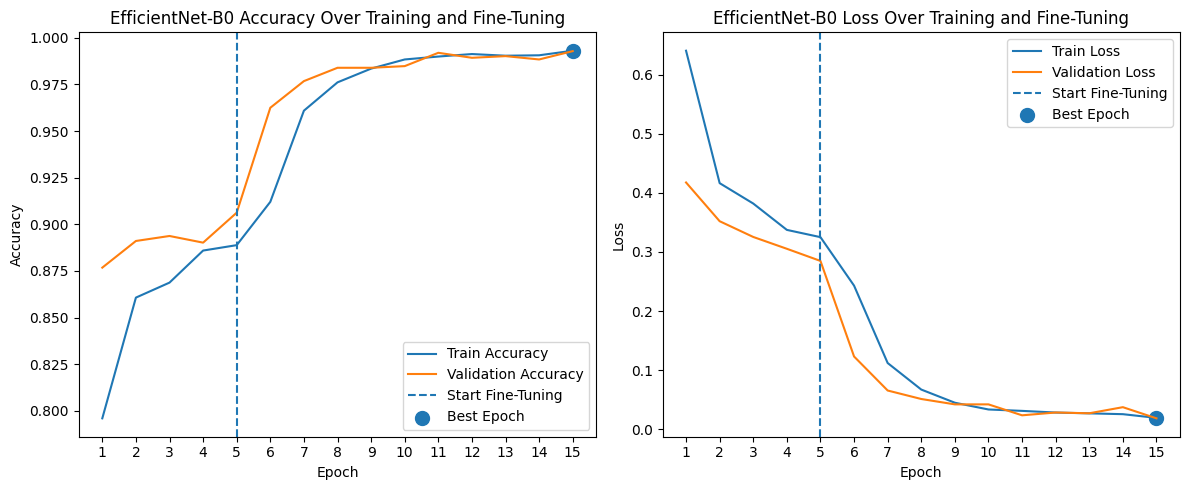

In [ ]:
# =========================
# Cell 35: EfficientNet Full Learning Curves
# =========================

total_eff_epochs = range(1, len(eff_train_losses) + 1)

plt.figure(figsize=(12,5))

# Accuracy
plt.subplot(1,2,1)

plt.plot(total_eff_epochs, eff_train_accuracies, label="Train Accuracy")
plt.plot(total_eff_epochs, eff_val_accuracies, label="Validation Accuracy")

plt.axvline(
    x=EFF_EPOCHS,
    linestyle="--",
    label="Start Fine-Tuning"
)

plt.scatter(
    best_epoch_eff,
    eff_val_accuracies[best_epoch_eff - 1],
    s=100,
    label="Best Epoch"
)

plt.title("EfficientNet-B0 Accuracy Over Training and Fine-Tuning")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.xticks(list(total_eff_epochs))
plt.legend()

# Loss
plt.subplot(1,2,2)

plt.plot(total_eff_epochs, eff_train_losses, label="Train Loss")
plt.plot(total_eff_epochs, eff_val_losses, label="Validation Loss")

plt.axvline(
    x=EFF_EPOCHS,
    linestyle="--",
    label="Start Fine-Tuning"
)

plt.scatter(
    best_epoch_eff,
    eff_val_losses[best_epoch_eff - 1],
    s=100,
    label="Best Epoch"
)

plt.title("EfficientNet-B0 Loss Over Training and Fine-Tuning")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.xticks(list(total_eff_epochs))
plt.legend()

plt.tight_layout()
plt.show()

- Visualized the complete EfficientNet-B0 training history across both stages:
  - Stage 1: feature extraction
  - Stage 2: fine-tuning
- The vertical line marks the transition to fine-tuning.
- The best epoch is highlighted based on the lowest validation loss.

In [ ]:
# =========================
# Cell 36: Load Best EfficientNet and Final Test Evaluation
# =========================

model_eff.load_state_dict(torch.load("best_efficientnet_b0.pth"))
model_eff.eval()

eff_final_test_loss, eff_final_test_acc = evaluate(
    model_eff,
    test_loader,
    criterion_eff,
    DEVICE
)

print("Best validation-checkpoint EfficientNet-B0 model loaded successfully.")
print(f"Final Test Loss: {eff_final_test_loss:.4f}")
print(f"Final Test Accuracy: {eff_final_test_acc:.4f}")

Best validation-checkpoint EfficientNet-B0 model loaded successfully.
Final Test Loss: 0.3529
Final Test Accuracy: 0.9500


### Final Test Evaluation — EfficientNet-B0

- Loaded the best EfficientNet-B0 checkpoint selected using the lowest validation loss.
- Evaluated the best model on the unseen test set.
- Final test loss = **0.3529**
- Final test accuracy = **0.9500 (95%)**

**Workflow:**  
Training + Validation → Save Best Checkpoint → Load Best Checkpoint → Final Test Evaluation

In [ ]:
# =========================
# Cell 37: EfficientNet Test Predictions
# =========================

eff_preds = []
eff_labels = []

model_eff.eval()

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(DEVICE)

        outputs = model_eff(images)
        _, preds = torch.max(outputs, 1)

        eff_preds.extend(preds.cpu().numpy())
        eff_labels.extend(labels.numpy())

eff_preds = np.array(eff_preds)
eff_labels = np.array(eff_labels)

print("EfficientNet-B0 test predictions generated successfully.")

EfficientNet-B0 test predictions generated successfully.


### Generate Test Predictions

- Generated predictions for all EfficientNet-B0 test images.
- Stored predicted classes and true labels for the confusion matrix and classification report.

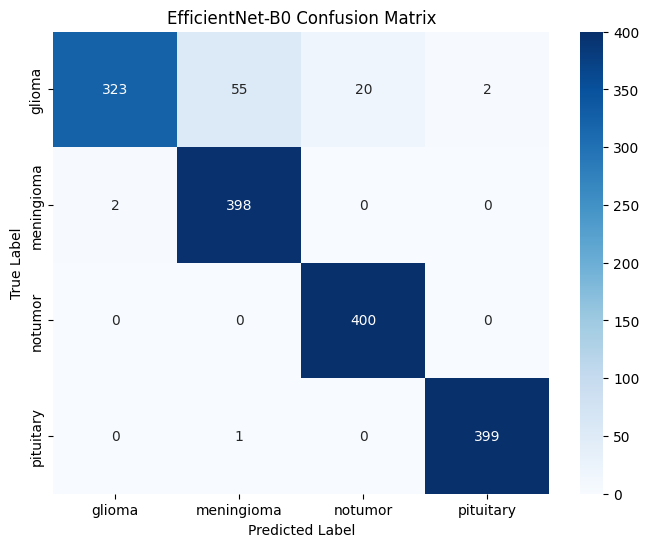

In [ ]:
# =========================
# Cell 38: EfficientNet Confusion Matrix
# =========================

eff_cm = confusion_matrix(eff_labels, eff_preds)

plt.figure(figsize=(8,6))

sns.heatmap(
    eff_cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=CLASS_NAMES,
    yticklabels=CLASS_NAMES
)

plt.title("EfficientNet-B0 Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")

plt.show()

- Visualized correct and incorrect EfficientNet-B0 predictions across classes.

In [ ]:
# =========================
# Cell 39: EfficientNet Classification Report
# =========================

eff_report = classification_report(
    eff_labels,
    eff_preds,
    target_names=CLASS_NAMES
)

print(eff_report)

              precision    recall  f1-score   support

      glioma       0.99      0.81      0.89       400
  meningioma       0.88      0.99      0.93       400
     notumor       0.95      1.00      0.98       400
   pituitary       1.00      1.00      1.00       400

    accuracy                           0.95      1600
   macro avg       0.95      0.95      0.95      1600
weighted avg       0.95      0.95      0.95      1600



### Classification Report — EfficientNet-B0

For each class:

- **Precision** = when the model predicts this class, how often is it correct?
- **Recall** = out of all real images of this class, how many did the model detect?
- **F1-score** = balance between precision and recall.
- **Support** = number of real test images in that class.

| Class | Precision | Recall | F1 | What it means |
|---|---:|---:|---:|---|
| Glioma | 0.99 | 0.81 | 0.89 | Very precise when predicting glioma, but missed some real glioma cases |
| Meningioma | 0.88 | 0.99 | 0.93 | Detected almost all real meningioma cases, but some other classes were predicted as meningioma |
| No Tumor | 0.95 | 1.00 | 0.98 | Detected all no-tumor images, but some tumor images were also predicted as no-tumor |
| Pituitary | 1.00 | 1.00 | 1.00 | Perfect performance on this test set |

### Key Observation

Glioma remained the most challenging class:

- Precision = **0.99**
- Recall = **0.81**

The model detected about **81% of real glioma cases**, meaning it missed around **19%**.

This is an improvement over ResNet18, which had glioma recall = **0.77**.

### Overall Metrics

- **Accuracy = 0.95** → about 95% of all test images were classified correctly.
- **Macro avg = 0.95**
- **Weighted avg = 0.95**

Each class has **400 test images**, so macro and weighted averages are effectively the same.

In [ ]:
# =========================
# Cell 40: ResNet18 vs EfficientNet-B0 Comparison
# =========================

import pandas as pd

comparison = pd.DataFrame({
    "Model": ["ResNet18", "EfficientNet-B0"],

    "Best Validation Loss": [best_val_loss, best_val_loss_eff],
    "Best Epoch": [best_epoch, best_epoch_eff],

    "Final Test Loss": [final_test_loss, eff_final_test_loss],
    "Final Test Accuracy": [final_test_acc, eff_final_test_acc],

    "Training Strategy": [
        "5 epochs frozen + 10 epochs fine-tuning",
        "5 epochs frozen + 10 epochs fine-tuning"
    ],

    "Main Observation": [
        "Strong baseline with good test performance",
        "Better validation loss and higher final test accuracy"
    ]
})

comparison

### ResNet18 vs EfficientNet-B0

Both models used the same two-stage transfer-learning strategy:

**5 epochs feature extraction → 10 epochs fine-tuning**

EfficientNet-B0 showed better overall results in this project:

- Lower best validation loss: **0.0184 vs 0.0465**
- Lower final test loss: **0.3529 vs 0.4325**
- Higher final test accuracy: **95.00% vs 93.56%**
- Improved glioma recall: **0.81 vs 0.77**

ResNet18 still provided a strong baseline, while EfficientNet-B0 produced slightly stronger overall classification performance.

In [ ]:
# =========================
# Cell 41: EfficientNet Grad-CAM Setup
# =========================

from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget

- Imported the Grad-CAM tools used for EfficientNet-B0 explainability.

In [ ]:
# =========================
# Cell 42: Prepare Correct EfficientNet Image for Grad-CAM
# =========================

correct_sample_eff = None

model_eff.eval()

with torch.no_grad():
    for img, label in test_dataset:
        input_tensor_eff = img.unsqueeze(0).to(DEVICE)

        output = model_eff(input_tensor_eff)
        pred = output.argmax(1).item()

        if pred == label:
            correct_sample_eff = (img, label, pred)
            break

image_tensor_eff, true_label_eff, predicted_class_eff = correct_sample_eff
input_tensor_eff = image_tensor_eff.unsqueeze(0).to(DEVICE)

print("True Label:", CLASS_NAMES[true_label_eff])
print("Predicted Label:", CLASS_NAMES[predicted_class_eff])

True Label: glioma
Predicted Label: glioma


- Selected a correctly classified EfficientNet-B0 test image.
- Prepared the image for Grad-CAM visualization.

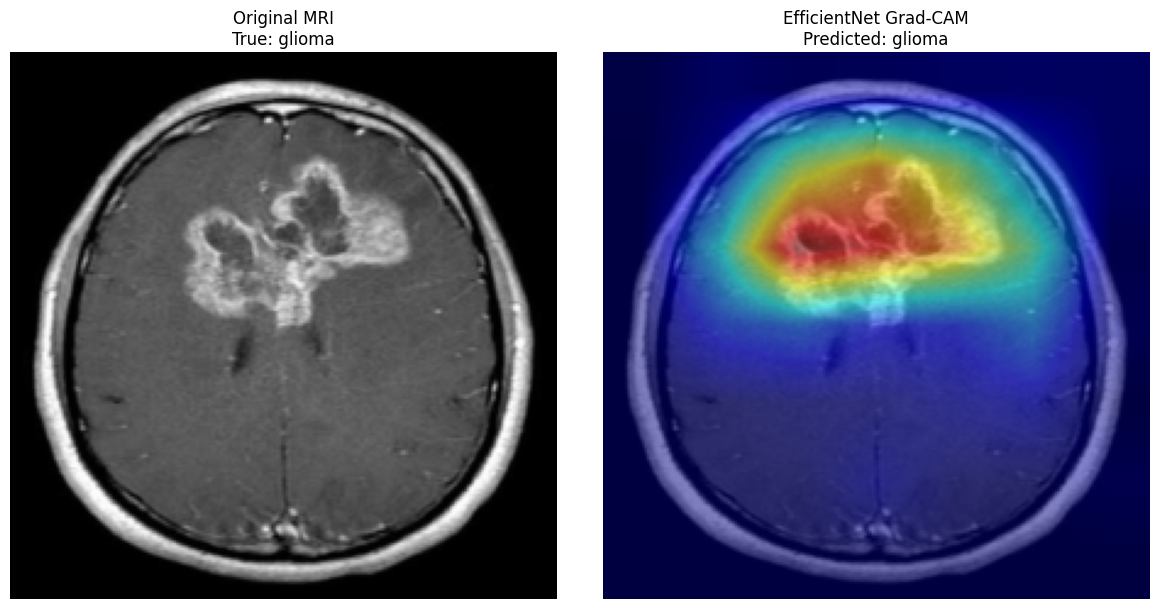

In [ ]:
# =========================
# Cell 43: EfficientNet Grad-CAM Heatmap
# =========================

# Target last convolutional block in EfficientNet-B0
target_layers_eff = [model_eff.features[-1]]

cam_eff = GradCAM(
    model=model_eff,
    target_layers=target_layers_eff
)

targets_eff = [ClassifierOutputTarget(predicted_class_eff)]

grayscale_cam_eff = cam_eff(
    input_tensor=input_tensor_eff,
    targets=targets_eff
)

grayscale_cam_eff = grayscale_cam_eff[0, :]

rgb_img_eff = image_tensor_eff.permute(1, 2, 0).numpy()

mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

rgb_img_eff = (rgb_img_eff * std) + mean
rgb_img_eff = rgb_img_eff.clip(0, 1)

visualization_eff = show_cam_on_image(
    rgb_img_eff,
    grayscale_cam_eff,
    use_rgb=True
)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(rgb_img_eff)
axes[0].set_title(f"Original MRI\nTrue: {CLASS_NAMES[true_label_eff]}")
axes[0].axis("off")

axes[1].imshow(visualization_eff)
axes[1].set_title(f"EfficientNet Grad-CAM\nPredicted: {CLASS_NAMES[predicted_class_eff]}")
axes[1].axis("off")

plt.tight_layout()
plt.show()

### Grad-CAM — Correct EfficientNet Prediction

- Generated a Grad-CAM heatmap for a correctly classified MRI image.
- Used the final EfficientNet feature block (`model_eff.features[-1]`) as the Grad-CAM target layer.
- Warmer regions indicate areas that had a stronger influence on the prediction.

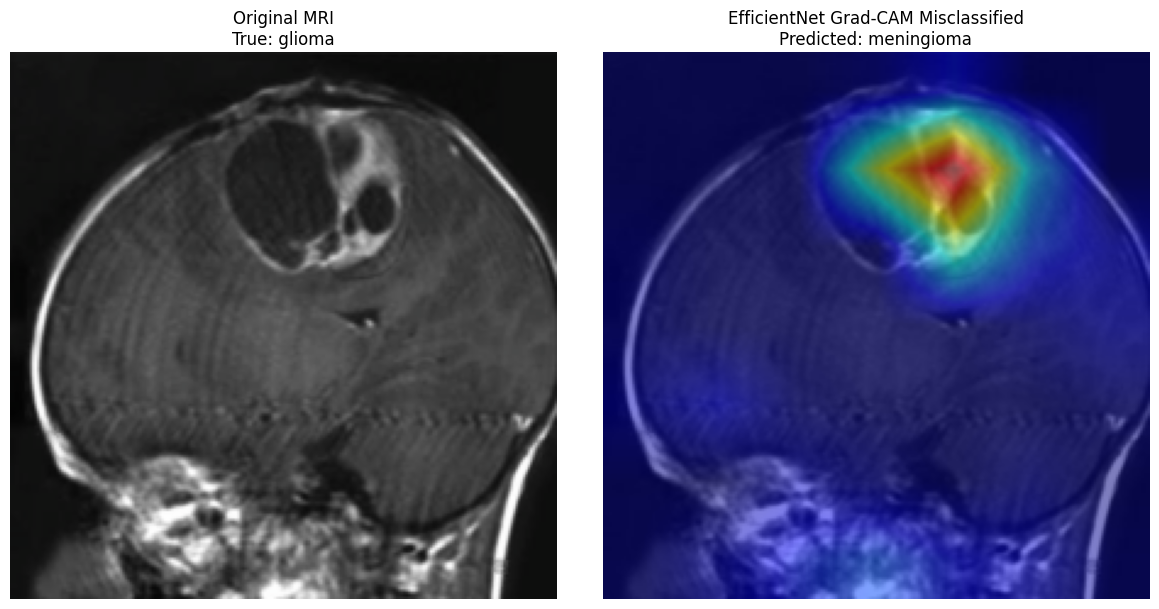

In [ ]:
# =========================
# Cell 44: EfficientNet Grad-CAM for Misclassified Image
# =========================

misclassified_sample_eff = None

model_eff.eval()

with torch.no_grad():
    for img, label in test_dataset:
        input_tensor_eff = img.unsqueeze(0).to(DEVICE)

        output = model_eff(input_tensor_eff)
        pred = output.argmax(1).item()

        if pred != label:
            misclassified_sample_eff = (img, label, pred)
            break

image_tensor_eff, true_label_eff, predicted_class_eff = misclassified_sample_eff
input_tensor_eff = image_tensor_eff.unsqueeze(0).to(DEVICE)

target_layers_eff = [model_eff.features[-1]]

cam_eff = GradCAM(
    model=model_eff,
    target_layers=target_layers_eff
)

targets_eff = [ClassifierOutputTarget(predicted_class_eff)]

grayscale_cam_eff = cam_eff(
    input_tensor=input_tensor_eff,
    targets=targets_eff
)

grayscale_cam_eff = grayscale_cam_eff[0, :]

rgb_img_eff = image_tensor_eff.permute(1, 2, 0).numpy()

mean = [0.485, 0.456, 0.406]
std  = [0.229, 0.224, 0.225]

rgb_img_eff = (rgb_img_eff * std) + mean
rgb_img_eff = rgb_img_eff.clip(0, 1)

visualization_eff = show_cam_on_image(
    rgb_img_eff,
    grayscale_cam_eff,
    use_rgb=True
)

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

axes[0].imshow(rgb_img_eff)
axes[0].set_title(f"Original MRI\nTrue: {CLASS_NAMES[true_label_eff]}")
axes[0].axis("off")

axes[1].imshow(visualization_eff)
axes[1].set_title(
    f"EfficientNet Grad-CAM Misclassified\nPredicted: {CLASS_NAMES[predicted_class_eff]}"
)
axes[1].axis("off")

plt.tight_layout()
plt.show()

### Grad-CAM — Misclassified EfficientNet Prediction

- Selected a misclassified EfficientNet-B0 test image and generated its Grad-CAM heatmap.
- Compared the true class with the incorrect predicted class.
- Used the heatmap to inspect which MRI regions influenced the incorrect prediction.

--------------------------------